<a href="https://colab.research.google.com/github/JulioLaz/RAG_alura_prueba/blob/main/RAG_OpenRouter_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 RAG Agent con OpenRouter + LangGraph

**Arquitectura:**
```
PDF(s) → Fragmentar → Embeddings (HuggingFace) → FAISS
                                                      ↓
Pregunta → [Agente LangGraph] → ¿RAG o LLM directo? → Respuesta
```

**Stack:**
- 🔗 LangChain + LangGraph
- 🧠 LLM: OpenRouter (cascada de modelos `:free`)
- 📐 Embeddings: HuggingFace `sentence-transformers` (sin API key)
- 📦 Vector Store: FAISS

**Requisito único:** API Key de [openrouter.ai](https://openrouter.ai) → guardarla en **Colab Secrets** como `OPENROUTER_KEY`

---
## PASO 1 — Instalación de dependencias

In [4]:
%%capture
!pip install langchain langchain-community langchain-text-splitters
!pip install langgraph
!pip install faiss-cpu
!pip install sentence-transformers
!pip install pypdf
!pip install requests

print('✅ Dependencias instaladas correctamente')

---
## PASO 2 — Configuración: API Key y parámetros

In [23]:
'''
RAG Agent con OpenRouter + LangGraph
Consulta PDFs locales via RAG o responde directamente usando LLM.
LLM: OpenRouter con cascada automática de modelos free.
Embeddings: HuggingFace sentence-transformers (sin API key).
'''

# ═══════════════════════════════════════════════════════
# RAG_OpenRouter_LangGraph.ipynb
# Versión: 1.0
# Cambios:
#   v1.0 - Pipeline completo RAG + LangGraph + OpenRouter cascada
# ═══════════════════════════════════════════════════════

import os
import requests
from datetime import datetime
from google.colab import userdata

# ── API Key desde Colab Secrets ──────────────────────────
OPENROUTER_KEY = userdata.get('OPENROUTER_KEY')
OPENROUTER_ENDPOINT = 'https://openrouter.ai/api/v1/chat/completions'
MAX_TOKENS = 512

# ── Lista de modelos free en orden de preferencia ───────
MODELOS_PREFERIDOS = [
    'deepseek/deepseek-r1:free',
    'deepseek/deepseek-chat-v3-0324:free',
    'microsoft/phi-4-reasoning:free',
    'tngtech/deepseek-r1t-chimera:free',
    'google/gemma-3-27b-it:free',
    'meta-llama/llama-3.3-70b-instruct:free',
    'mistralai/mistral-small-3.1-24b-instruct:free',
    'google/gemma-3-12b-it:free',
    'google/gemma-3-4b-it:free',
    'qwen/qwen3-4b:free',
    'meta-llama/llama-3.2-3b-instruct:free',

]

ERRORES_REINTENTABLES = {429, 404, 503}

print(f'✅ Configuración cargada | {datetime.now().strftime("%H:%M:%S")}')
print(f'   🔑 API Key: {"OK" if OPENROUTER_KEY else "❌ NO ENCONTRADA"}')
print(f'   🤖 Modelos en cascada: {len(MODELOS_PREFERIDOS)}')

✅ Configuración cargada | 20:47:07
   🔑 API Key: OK
   🤖 Modelos en cascada: 11


---
## PASO 3 — LLM Custom: OpenRouter con cascada automática

In [24]:
from langchain_core.language_models.llms import LLM
from typing import Optional, List
import time

class OpenRouterCascadaLLM(LLM):
    """
    LLM custom para LangChain que usa OpenRouter.
    Si un modelo devuelve 429/404/503, prueba el siguiente de la lista.
    """

    @property
    def _llm_type(self) -> str:
        return 'openrouter_cascada'

    def _consultar_modelo(self, modelo: str, prompt: str) -> tuple:
        """Intenta un modelo. Retorna (texto_respuesta | None, status_code)."""
        headers = {
            'Authorization': f'Bearer {OPENROUTER_KEY}',
            'Content-Type': 'application/json',
        }
        payload = {
            'model': modelo,
            'max_tokens': MAX_TOKENS,
            'messages': [{'role': 'user', 'content': prompt}]
        }
        try:
            resp = requests.post(
                OPENROUTER_ENDPOINT, headers=headers,
                json=payload, timeout=30
            )
            if resp.status_code == 200:
                texto = resp.json()['choices'][0]['message']['content']
                return texto, 200
            return None, resp.status_code
        except requests.exceptions.Timeout:
            return None, 408

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        """Prueba modelos en cascada hasta obtener respuesta."""
        print(f'\n⏳ Consultando OpenRouter...')
        for modelo in MODELOS_PREFERIDOS:
            print(f'   🔄 {modelo}...', end=' ', flush=True)
            texto, status = self._consultar_modelo(modelo, prompt)
            if status == 200:
                print('✅')
                return texto
            elif status in ERRORES_REINTENTABLES:
                print(f'⚠️  {status} — siguiente')
                time.sleep(3)   # ← espera 3s antes del siguiente modelo
            elif status == 408:
                print('⏱️  Timeout — siguiente')
            else:
                print(f'❌ Error {status} — siguiente')
        raise RuntimeError('❌ Ningún modelo respondió correctamente.')


# Instanciar el LLM
llm = OpenRouterCascadaLLM()
print('✅ LLM OpenRouter con cascada listo')

✅ LLM OpenRouter con cascada listo


---
## PASO 4 — Carga y fragmentación de PDFs

In [25]:
from google.colab import files
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── Subir PDFs ───────────────────────────────────────────
print('📂 Seleccioná uno o más archivos PDF...')
os.makedirs('PDFs', exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
    os.rename(archivo, f'PDFs/{archivo}')

# ── Cargar documentos ────────────────────────────────────
documentos = []
for archivo in os.listdir('PDFs'):
    if archivo.endswith('.pdf'):
        loader = PyPDFLoader(f'PDFs/{archivo}')
        documentos.extend(loader.load())

print(f'\n📄 Documentos cargados: {len(documentos)} páginas')

# ── Fragmentar ───────────────────────────────────────────
divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=['\n\n', '\n', '. ', ' ', '']
)
fragmentos = divisor.split_documents(documentos)

print(f'✂️  Fragmentos generados: {len(fragmentos)}')

📂 Seleccioná uno o más archivos PDF...


KeyboardInterrupt: 

## Cargar docx:

In [26]:
from google.colab import files
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── Instalar soporte docx ────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'docx2txt'], check=True)

# ── Subir archivos ───────────────────────────────────────
print('📂 Seleccioná uno o más archivos PDF o DOCX...')
os.makedirs('PDFs', exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
    os.rename(archivo, f'PDFs/{archivo}')

# ── Cargar documentos (PDF y DOCX) ───────────────────────
documentos = []
for archivo in os.listdir('PDFs'):
    ruta = f'PDFs/{archivo}'
    if archivo.endswith('.pdf'):
        loader = PyPDFLoader(ruta)
    elif archivo.endswith('.docx'):
        loader = Docx2txtLoader(ruta)
    else:
        print(f'⚠️  Formato no soportado: {archivo}')
        continue
    documentos.extend(loader.load())

print(f'\n📄 Documentos cargados: {len(documentos)} páginas')

# ── Fragmentar ───────────────────────────────────────────
divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=['\n\n', '\n', '. ', ' ', '']
)
fragmentos = divisor.split_documents(documentos)
print(f'✂️  Fragmentos generados: {len(fragmentos)}')

📂 Seleccioná uno o más archivos PDF o DOCX...


Saving UNIDAD III - TEMA 4 - Ética aristótélica. Lo bueno es la felicidad.docx to UNIDAD III - TEMA 4 - Ética aristótélica. Lo bueno es la felicidad.docx

📄 Documentos cargados: 1 páginas
✂️  Fragmentos generados: 22


---
## PASO 5 — Embeddings con HuggingFace + índice FAISS

> ⏳ Este paso tarda ~1-2 minutos la primera vez (descarga el modelo de embeddings ~90MB)

In [27]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# ── Modelo de embeddings (multilingüe, sin API key) ──────
print('🔄 Cargando modelo de embeddings HuggingFace...')
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)
print('✅ Modelo de embeddings listo')

# ── Crear índice FAISS ───────────────────────────────────
print('\n🔄 Creando índice FAISS (puede tardar según cantidad de fragmentos)...')
inicio = datetime.now()

vectorstore = FAISS.from_documents(fragmentos, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

elapsed = (datetime.now() - inicio).total_seconds()
print(f'✅ Índice FAISS creado en {elapsed:.1f}s')
print(f'   📊 Vectores indexados: {vectorstore.index.ntotal}')

🔄 Cargando modelo de embeddings HuggingFace...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo de embeddings listo

🔄 Creando índice FAISS (puede tardar según cantidad de fragmentos)...
✅ Índice FAISS creado en 6.4s
   📊 Vectores indexados: 22


---
## PASO 6 — Agente LangGraph: clasifica y responde

In [28]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# ── Estado del agente ────────────────────────────────────
class AgentState(TypedDict):
    pregunta: str
    fuente: str      # 'RAG' o 'DIRECTO'
    contexto: str
    respuesta: str


# ── Nodo 1: Clasificador ─────────────────────────────────
def nodo_clasificador(state: AgentState) -> AgentState:
    """Decide si responder con RAG (documentos) o directo (LLM)."""
    pregunta = state['pregunta']
    prompt = f"""Eres un clasificador. Dada la pregunta, decide si se debe
responder buscando en los DOCUMENTOS cargados o con conocimiento general.

Reglas:
- Responde SOLO 'RAG' si la pregunta se refiere al contenido de los documentos.
- Responde SOLO 'DIRECTO' si la pregunta es general o de conocimiento amplio.

Pregunta: {pregunta}

Responde SOLO con una palabra (RAG o DIRECTO):"""

    # nodo_clasificador  (línea 28)
    decision = llm.invoke(prompt).strip().upper()

    # nodo_rag  (dentro de nodo_rag)
    respuesta = llm.invoke(prompt)

    # nodo_directo
    respuesta = llm.invoke(prompt)

    fuente = 'RAG' if 'RAG' in decision else 'DIRECTO'
    print(f'\n🧭 Clasificación: {fuente}')
    return {**state, 'fuente': fuente}


# ── Nodo 2: Búsqueda en documentos (RAG) ─────────────────
def nodo_rag(state: AgentState) -> AgentState:
    """Recupera contexto relevante del vectorstore y responde."""
    pregunta = state['pregunta']
    docs = retriever.invoke(pregunta)
    contexto = '\n\n---\n\n'.join(doc.page_content for doc in docs)

    prompt = f"""Eres un asistente experto. Responde ÚNICAMENTE basándote
en el contexto provisto. Si la información no está, dilo claramente.

Contexto:
{contexto}

Pregunta: {pregunta}

Respuesta:"""

    respuesta = llm.invoke(prompt)
    return {**state, 'contexto': contexto, 'respuesta': respuesta}


# ── Nodo 3: Respuesta directa (sin docs) ─────────────────
def nodo_directo(state: AgentState) -> AgentState:
    """Responde con conocimiento general del LLM."""
    pregunta = state['pregunta']
    prompt = f"""Responde la siguiente pregunta de forma clara y concisa.

Pregunta: {pregunta}

Respuesta:"""

    respuesta = llm.invoke(prompt)
    return {**state, 'contexto': '(sin documentos)', 'respuesta': respuesta}


# ── Función de enrutamiento ───────────────────────────────
def decidir_fuente(state: AgentState) -> str:
    return 'RAG_elegido' if state['fuente'] == 'RAG' else 'Directo_elegido'


# ── Construir el grafo ────────────────────────────────────
grafo = StateGraph(AgentState)

grafo.add_node('clasificador', nodo_clasificador)
grafo.add_node('rag',          nodo_rag)
grafo.add_node('directo',      nodo_directo)

grafo.add_edge(START, 'clasificador')
grafo.add_conditional_edges(
    'clasificador',
    decidir_fuente,
    {'RAG_elegido': 'rag', 'Directo_elegido': 'directo'}
)
grafo.add_edge('rag',     END)
grafo.add_edge('directo', END)

agente = grafo.compile()

print('✅ Agente LangGraph compilado')
print('\n📊 Grafo:')
print('   START → [Clasificador] → RAG o Directo → END')

✅ Agente LangGraph compilado

📊 Grafo:
   START → [Clasificador] → RAG o Directo → END


---
## PASO 7 — (Opcional) Visualizar el grafo

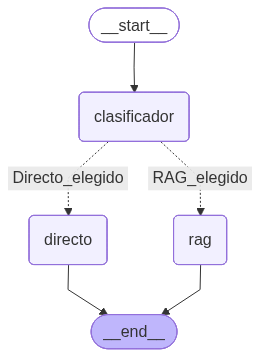

In [29]:
from IPython.display import Image, display

try:
    imagen = agente.get_graph().draw_mermaid_png()
    display(Image(imagen))
except Exception as e:
    print(f'ℹ️  No se pudo renderizar el grafo: {e}')
    print('   (No afecta el funcionamiento del agente)')

---
## PASO 8 — Función principal y pruebas

In [30]:
def ejecutar_agente(pregunta: str) -> str:
    """
    Ejecuta el pipeline RAG completo para una pregunta.
    Retorna la respuesta final como string.
    """
    inicio = datetime.now()
    print('=' * 60)
    print(f'❓ Pregunta: {pregunta}')
    print('─' * 60)

    resultado = agente.invoke({
        'pregunta': pregunta,
        'fuente': '',
        'contexto': '',
        'respuesta': ''
    })

    elapsed = (datetime.now() - inicio).total_seconds()
    print('─' * 60)
    print(f'📌 Fuente:    {resultado["fuente"]}')
    print(f'⏱️  Tiempo:    {elapsed:.1f}s')
    print(f'\n💬 Respuesta:\n{resultado["respuesta"]}')
    print('=' * 60)

    return resultado['respuesta']

In [31]:
# ── Prueba 1: Pregunta sobre el documento (debería usar RAG) ──
ejecutar_agente('¿De qué trata el documento cargado?')

❓ Pregunta: ¿De qué trata el documento cargado?
────────────────────────────────────────────────────────────

⏳ Consultando OpenRouter...
   🔄 deepseek/deepseek-r1:free... ⚠️  404 — siguiente
   🔄 deepseek/deepseek-chat-v3-0324:free... ⚠️  404 — siguiente
   🔄 microsoft/phi-4-reasoning:free... ⚠️  404 — siguiente
   🔄 tngtech/deepseek-r1t-chimera:free... ⚠️  404 — siguiente
   🔄 google/gemma-3-27b-it:free... ⚠️  429 — siguiente
   🔄 meta-llama/llama-3.3-70b-instruct:free... ⚠️  429 — siguiente
   🔄 mistralai/mistral-small-3.1-24b-instruct:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-12b-it:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-4b-it:free... ✅

⏳ Consultando OpenRouter...
   🔄 deepseek/deepseek-r1:free... ⚠️  404 — siguiente
   🔄 deepseek/deepseek-chat-v3-0324:free... ⚠️  404 — siguiente
   🔄 microsoft/phi-4-reasoning:free... ⚠️  404 — siguiente
   🔄 tngtech/deepseek-r1t-chimera:free... ⚠️  404 — siguiente
   🔄 google/gemma-3-27b-it:free... ⚠️  429 — siguiente
   🔄 meta-lla

'El documento trata sobre la filosofía de Aristóteles, específicamente sobre su concepción de la felicidad y su relación con el fin último.\n'

In [32]:
# ── Prueba 2: Pregunta general (debería ir DIRECTO) ───────────
ejecutar_agente('¿Cuántos mundiales de fútbol tiene Brasil?')

❓ Pregunta: ¿Cuántos mundiales de fútbol tiene Brasil?
────────────────────────────────────────────────────────────

⏳ Consultando OpenRouter...
   🔄 deepseek/deepseek-r1:free... ⚠️  404 — siguiente
   🔄 deepseek/deepseek-chat-v3-0324:free... ⚠️  404 — siguiente
   🔄 microsoft/phi-4-reasoning:free... ⚠️  404 — siguiente
   🔄 tngtech/deepseek-r1t-chimera:free... ⚠️  404 — siguiente
   🔄 google/gemma-3-27b-it:free... ⚠️  429 — siguiente
   🔄 meta-llama/llama-3.3-70b-instruct:free... ⚠️  429 — siguiente
   🔄 mistralai/mistral-small-3.1-24b-instruct:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-12b-it:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-4b-it:free... ✅

⏳ Consultando OpenRouter...
   🔄 deepseek/deepseek-r1:free... ⚠️  404 — siguiente
   🔄 deepseek/deepseek-chat-v3-0324:free... ⚠️  404 — siguiente
   🔄 microsoft/phi-4-reasoning:free... ⚠️  404 — siguiente
   🔄 tngtech/deepseek-r1t-chimera:free... ⚠️  404 — siguiente
   🔄 google/gemma-3-27b-it:free... ⚠️  429 — siguiente
   🔄 m

RuntimeError: ❌ Ningún modelo respondió correctamente.

In [34]:
# ── Prueba libre ──────────────────────────────────────────────
mi_pregunta = input('❓ Escribí tu pregunta: ').strip()
if mi_pregunta:
    ejecutar_agente(mi_pregunta)

❓ Escribí tu pregunta: que es la felicidad para aristoteles?
❓ Pregunta: que es la felicidad para aristoteles?
────────────────────────────────────────────────────────────

⏳ Consultando OpenRouter...
   🔄 deepseek/deepseek-r1:free... ⚠️  404 — siguiente
   🔄 deepseek/deepseek-chat-v3-0324:free... ⚠️  404 — siguiente
   🔄 microsoft/phi-4-reasoning:free... ⚠️  404 — siguiente
   🔄 tngtech/deepseek-r1t-chimera:free... ⚠️  404 — siguiente
   🔄 google/gemma-3-27b-it:free... ⚠️  429 — siguiente
   🔄 meta-llama/llama-3.3-70b-instruct:free... ⚠️  429 — siguiente
   🔄 mistralai/mistral-small-3.1-24b-instruct:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-12b-it:free... ⚠️  429 — siguiente
   🔄 google/gemma-3-4b-it:free... ⚠️  429 — siguiente
   🔄 qwen/qwen3-4b:free... ⚠️  429 — siguiente
   🔄 meta-llama/llama-3.2-3b-instruct:free... ⚠️  429 — siguiente


RuntimeError: ❌ Ningún modelo respondió correctamente.